In [1]:
# load a matrix from a space-separated file and show it as an image
import sys
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/')
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import os
from stat_utils import bic_gaussian_from_rmse
#result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_try2/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_basicPlusInjPlusUfb/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_XLsigmoidFull_noAwithUfb/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_XLsigmoidFull/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_XLsigmoidFRMSprop/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_basicBwdCapatRMSprop/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_basicBwdCapatRMSprop_inj/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_basicBwdCapatRMSprop_LRflr1e/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/deleteme_u/' #U fbk
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/experimental_um1a/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/zz1_deleteme/'


# result_path_aux = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_basicBwdCapatRMSprop_M2noAnoLRD_injLim0p45/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_basicBwdCapatRMSprop_M2noAnoLRD_inj_REDO/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_basicBwdCapatRMSprop_M2noAnoLRD_inj_REDO_Noi/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_basicBwdCapatRMSprop_M2noAnoLRD_inj_REDOsigmoid/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_basicBwdCapatRMSprop_M2noAnoLRD_inj/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/state_space_2rates/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/state_space_2ratesBound/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/state_space_2ratesNLdecays/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/state_space_1ratesNLdecaysBound/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/state_space_2ratesNLdecaysBound/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/state_space_1ratesNLdecaysNLerror/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/clnn_2ratesU_Bound_v2/'

# result_path ='/homes/ar2342/one_more_dir/contextual_frogs/results_part2/zz1_deleteme/'
result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/lerner_group1_m2/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/lerner_group1_m1/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/clnn_2ratesU_Bound_v3LNG/'


# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_basicBwdCapatRMSprop_M2noAnoLRD_inj_decCap0p3/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_basicBwdCapatRMSprop_M2noAnoLRD_inj_REDO_NoiNewIC/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_basicBwdCapatRMSprop_M2noAnoLRD_inj_REDO_NoiNewICSWeights/'


# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_basicBwdCapatRMSprop_M2noAnoLRD_injMU/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_tryMU5opt3withSaves/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_tryMU5opt3withSavesRMSprop/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_tryMU5opt3withSavesRMSprop_LRflr1em1/'



# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_tryMulti102/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_tryMulti104trySchV2_m2u/'

In [2]:
def compute_k_params(model_state_dict, 
                     exclude_by_startwith=['_'], 
                     exclude_by_name=['sigma_x'], 
                     count_for_one={'sigma_b', 'direct_injection_scale','output_scale','u_feedback_scale'}):
    k_params = 0
    for key in model_state_dict:
        if any([key.startswith(excl) for excl in exclude_by_startwith]):
            continue
        if key in exclude_by_name:
            continue
        param_tensor = model_state_dict[key]
        this_param_size = param_tensor.shape[-1] if key not in count_for_one else 1
        print(f'param: {key}, size: {this_param_size}')
        k_params += this_param_size
    return k_params

In [3]:
#read saved model parameters
model_state_dict = torch.load(os.path.join(result_path, 'model_state_dict.pt'), map_location='cpu')
# if result_path_aux is not None:
#     model_state_dict_aux = torch.load(os.path.join(result_path_aux, 'model_state_dict.pt'), map_location='cpu')
# plt.hist(model_state_dict['output_scale'].cpu().numpy(), bins=30)
k_params = compute_k_params(model_state_dict)
print(f'detected k_params: {k_params}')

param: log_learning_rate, size: 2
param: sp_weight_decay, size: 2
detected k_params: 4


In [4]:


a_exp = np.loadtxt(os.path.join(result_path, 'a_exp.txt'))
a_pred = np.loadtxt(os.path.join(result_path, 'a_pred.txt'))


seeds = 128 # 128*2#*2 # 18#72#18 #128
subjs = a_exp.shape[1] // seeds

In [5]:
rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])

rmse_ = np.sqrt(np.nanmean((a_exp - a_pred)[192:,:] ** 2,axis=0)).reshape([subjs, seeds]) 
n_samples = np.sum(~np.isnan(a_exp),axis=0).reshape([subjs, seeds])
#ensure n_samples is same in every row
assert np.all(n_samples == n_samples[:, [0]])
n_samples = n_samples[:, 0]

best_seed_idx = np.nanargmin(rmse, axis=1)
# best_rmse = np.nanmin(rmse, axis=1)
best_rmse = rmse[np.arange(subjs), best_seed_idx]
best_rmse_ = rmse_[np.arange(subjs), best_seed_idx]

/tmp/ipykernel_2810281/4168741050.py:3: RuntimeWarning: Mean of empty slice
  rmse_ = np.sqrt(np.nanmean((a_exp - a_pred)[192:,:] ** 2,axis=0)).reshape([subjs, seeds])


In [6]:
subjs

16

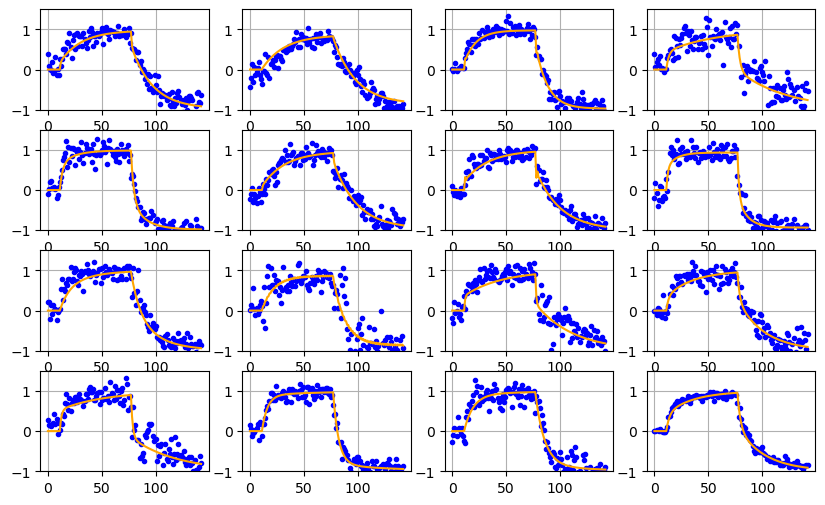

In [7]:

plt.figure(figsize=(10, 6))
plt.subplot(4, 4, 1)
cnt=0
for ii, (this_exp, this_pred) in enumerate(zip(a_exp.T, a_pred.T)):
    plt.subplot(4, 4, 1 + ii//seeds)
    polarity = np.sign(np.nanmean(this_exp[:175]))
    if ii % seeds == 0:
        plt.plot(polarity*this_exp,'.', label='Experimental', color='blue')
    if ii % seeds == best_seed_idx[ii//seeds]:
        plt.plot(polarity*this_pred, label='Predicted', color='orange')
        plt.grid() #; print(cnt); cnt+=1
        plt.ylim([-1,1.5])
    # plt.xlabel('trials')
    # plt.ylabel('adaptation')
    # plt.title('Experimental vs Predicted Data')


In [8]:
# rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])
# n_samples = np.sum(~np.isnan(a_exp),axis=0).reshape([subjs, seeds])
# best_seed_idx = np.argmin(rmse, axis=1)
# best_rmse = rmse[np.arange(subjs), best_seed_idx]

In [9]:
these_bics = [bic_gaussian_from_rmse(this_rmse, n=this_n, k=k_params) for this_rmse, this_n in zip(best_rmse, n_samples)]

In [10]:
coin_bics_path = '/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/coin_bics1000.txt'
coin_bics = np.loadtxt(coin_bics_path)

In [11]:
n_samples

array([143, 143, 143, 143, 143, 143, 143, 143, 143, 143, 143, 143, 143,
       143, 143, 143])

<StemContainer object of 3 artists>

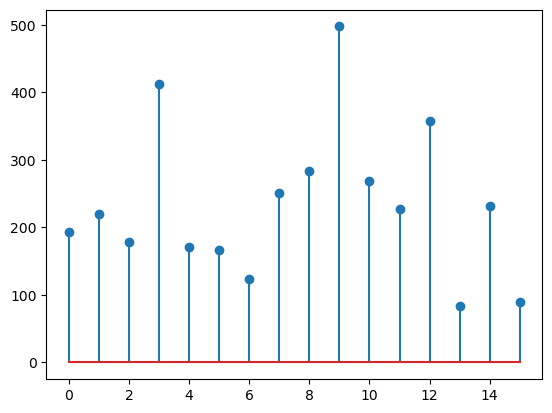

In [12]:
plt.stem(these_bics-coin_bics)

In [13]:
best_rmse

array([0.15920459, 0.16772618, 0.1204218 , 0.30833033, 0.16624149,
       0.16196564, 0.13118499, 0.16402807, 0.19749587, 0.31096261,
       0.22018307, 0.18023948, 0.25272412, 0.13003122, 0.19772032,
       0.0767599 ])

In [14]:
these_bics-coin_bics

array([193.11395088, 220.21076391, 178.7072576 , 412.30840034,
       171.14125961, 166.79276752, 122.88481057, 250.15623579,
       283.85124384, 497.34307519, 269.17476085, 227.87269932,
       356.69944677,  83.50081162, 231.35398828,  89.90165722])

In [15]:
dual_rate_bics = np.loadtxt('/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/dual_rate_bics_v1.txt')


Text(11, -50, 'SR')

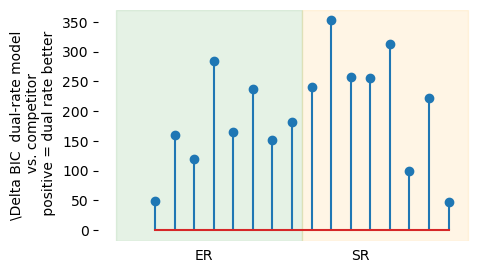

In [16]:
plt.figure(figsize=(5, 3))
plt.stem(np.arange(1, 17), these_bics - dual_rate_bics)
plt.axvspan(-1, 8.5, color='green', alpha=0.1)
plt.axvspan(8.5,17, color='orange', alpha=0.1)
plt.box('off')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.xticks([])
# plt.ylabel('\Delta BIC  dual-rate model\n linear decay vs. power law decay \n positive = linear better')
plt.ylabel('\Delta BIC  dual-rate model\n  vs. competitor \n positive = dual rate better')
plt.text(3,-50,'ER')
plt.text(8+3,-50,'SR')


In [17]:
ref_temp_rmse = np.array([0.14388285, 0.13275064, 0.18496574, 0.09147181, 0.16228775,
       0.1605799 , 0.18684085, 0.13883465, 0.11473347, 0.169773  ,
       0.20617779, 0.20484355, 0.10975336, 0.09605098, 0.18166255,
       0.1527941 , 0.16023854, 0.13980691, 0.16267194, 0.13959636,
       0.1403273 , 0.14730662, 0.12016405, 0.15779249])

In [18]:
# np.sum(best_rmse - ref_temp_rmse)

In [19]:
best_seed_idx_within_batch = best_seed_idx +(np.arange(subjs) * seeds)

#create a new model state dict with only the best seeds (seeds are the leading dimension of each parameter tensor)
best_model_state_dict = {}
for key, value in model_state_dict.items():
        print(key, value.shape)
        best_model_state_dict[key] = value[best_seed_idx_within_batch] if not key.startswith('_') else value


log_learning_rate torch.Size([2048, 2])
sp_weight_decay torch.Size([2048, 2])
sigma_x torch.Size([2048])
_z_biases torch.Size([1])
_w_in torch.Size([1])
_w_inq torch.Size([1])


In [20]:
from models_part2 import BatchedElboGenerativeModelTopMulti
import yaml
from types import SimpleNamespace
args_path = os.path.join(result_path, 'args.yaml')
with open(args_path, 'r') as f:
    args_dict = yaml.unsafe_load(f) #safe_load(f)
args = SimpleNamespace(**args_dict)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [21]:
import pickle

In [22]:
args_path

'/homes/ar2342/one_more_dir/contextual_frogs/results_part2/lerner_group1_m2/args.yaml'

In [23]:
args.bs = subjs  #set batch size to number of subjects

In [24]:
model = BatchedElboGenerativeModelTopMulti(device=device, args=args).to(device)
model.get_biases_and_w_in(args.n, device=device)
model.load_state_dict(best_model_state_dict)

<All keys matched successfully>

In [25]:
def local_eval_paradigms(model, playlist_file, args):
    with open(playlist_file, 'rb') as f:
        playlist = pickle.load(f)

    model.eval()
    with torch.no_grad():
        outputs = {}
        for paradigm_name,paradigm in playlist.items():
            print(f'evaluating paradigm {paradigm_name} with {len(paradigm)} steps')
            ys = torch.tensor(paradigm, device=next(model.parameters()).device)
            #duplicate ys across batch size
            ys = ys.unsqueeze(0).repeat(args.bs, 1)  # [bs, t]
            # noises = torch.randn((args.bs, ys.shape[1]), device=next(model.parameters()).device) * model.sigma_x  # [bs, t]
            noises = torch.zeros((args.bs, ys.shape[1]), device=next(model.parameters()).device)  # [bs, t]
            noises = [noises[:, t_idx] for t_idx in range(noises.shape[1])]
            ys = [ys[:, t_idx] for t_idx in range(ys.shape[1])]
            print(f'noises shape: {noises[0].shape}, ys shape: {ys[0].shape}')
            model_setting = args.model
            outputs_ = model.f(args.n,
                                noises,
                                ys,  
                                model_setting,
                                qs=None,
                                )
            outputs[paradigm_name] = np.array([z.cpu().numpy().reshape(-1) for z in outputs_]) 
    return outputs

In [26]:
paradigm_file='/homes/ar2342/one_more_dir/contextual_frogs/signoffrepertoire4.3.pkl'
# force_model_params(model, forced_params)

ooo = local_eval_paradigms(model, paradigm_file, args)

evaluating paradigm savings with 440 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm AB0 with 270 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])


/scratch/ar2342/miconda3/envs/py_frogs/lib/python3.9/site-packages/torch/nn/functional.py:1967: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


evaluating paradigm AB1 with 283 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm AB2 with 311 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm AB3 with 382 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm AB4 with 500 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm AB5 with 680 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm spontaneous with 340 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm evoked with 340 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm visw1p2 with 1150 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm visw1p1 with 900 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm visw1p3 with 1150 steps
noises shape: torch.Size([16]), ys shape: torch.Size([

In [27]:
pooling_fun = np.nanmedian
# pooling_fun = np.nanmean

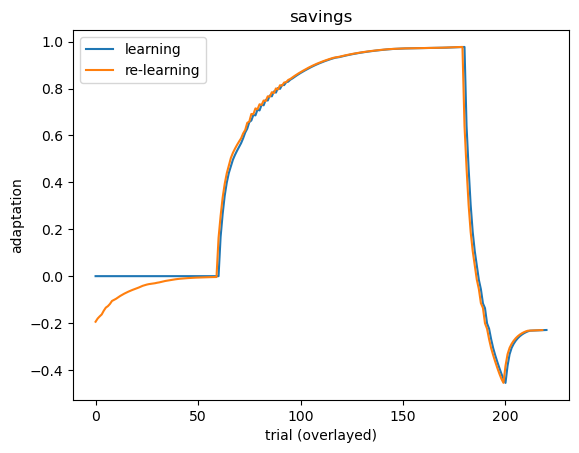

In [28]:
plt.plot(pooling_fun(ooo['savings'][:221], axis=1) , label='learning')
plt.plot(pooling_fun(ooo['savings'][221:], axis=1), label='re-learning')
# for subj in range(subjs):
    # plt.plot(ooo['savings'][221:, subj], color='gray', alpha=0.3)
plt.title('savings')
plt.xlabel('trial (overlayed)')
plt.ylabel('adaptation')
plt.legend()

In [29]:
from dsp_utils import smooth_signal

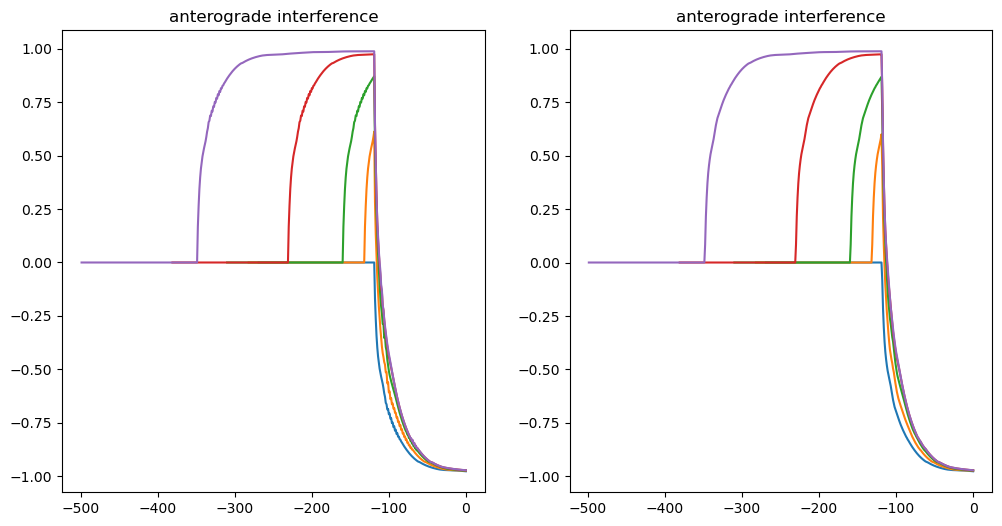

In [30]:
ant_list = [f'AB{i}' for i in range(0,5)]

plt.figure(figsize=(12,6))
for ii, smooth_fun in enumerate([lambda x: x,lambda x: smooth_signal(x, 2)]):
    plt.subplot(1,2,ii+1)
    plt.title('anterograde interference')
    for ant in ant_list:
        x_data = np.arange(len(ooo[ant].mean(axis=1)))
        # plt.plot(x_data,smooth_fun(pooling_fun(ooo[ant], axis=1)))
        plt.plot(x_data-np.max(x_data),smooth_fun(pooling_fun(ooo[ant], axis=1)))
        # for subj in range(subjs):
        #     plt.plot(x_data-np.max(x_data),ooo[ant][:, subj], color='gray', alpha=0.3)

In [31]:
# paradigms = ['frogs', 'antifrogs']

# plt.figure(figsize=(12,6))
# for ii, smooth_fun in enumerate([lambda x: x,lambda x: smooth_signal(x, 2)]):
#     plt.subplot(1,2,ii+1)
#     plt.title('anterograde interference')
#     for paradigm in paradigms:
#         x_data = np.arange(len(ooo[paradigm].mean(axis=1)))
#         # plt.plot(x_data,smooth_fun(pooling_fun(ooo[ant], axis=1)))
#         plt.plot(x_data-np.max(x_data),smooth_fun(pooling_fun(ooo[ant], axis=1)))

Text(0.5, 1.0, 'environmental consistency')

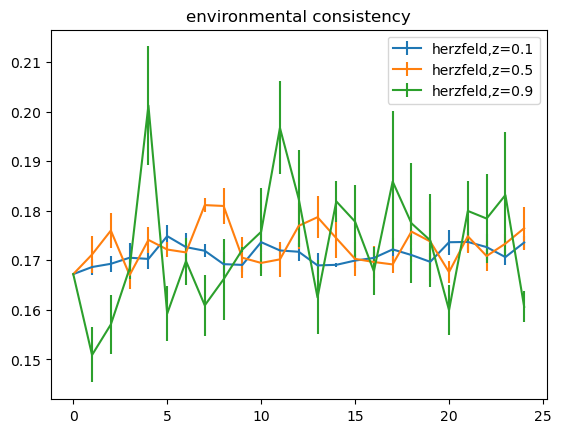

In [32]:
deltas_by_super_scenario = {}
for i, this_data in enumerate([ooo]):
    # plt.subplot(4,4,i+1)
    for iz, z in enumerate(ooo.keys()):
        if 'herzfeld' not in z:
            continue
        else:
            scenario = z
            super_scenario = z.split('$')[0]
        deltas = []
        mm = lambda x: np.mean(x,axis=0)
        # scenario = f'herzfeld,z={z}'
        # this_result = this_data[scenario].mean(axis=1)
        this_result = pooling_fun(this_data[scenario],axis=1)
        pointer = 0
        for bb in range(25):
            block_length = len(this_result)//25
            # pointer += block_length
            # deltas.append(this_result[pointer-1]-this_result[pointer-3])
            deltas.append(this_result[pointer+2]-this_result[pointer])
            pointer += block_length

        if super_scenario not in deltas_by_super_scenario:
            deltas_by_super_scenario[super_scenario] = []
        deltas_by_super_scenario[super_scenario].append(deltas)
        # plt.plot(deltas,'x',label = f'z={z}')
        # plt.title('environmental consistency')
    # plt.legend(loc='upper right')
plt.figure()
for k in deltas_by_super_scenario:
    # plt.plot(np.mean(deltas_by_super_scenario[k],axis=0),label=k)
    #present with error bars
    data = np.array(deltas_by_super_scenario[k])
    mean = np.mean(data,axis=0)
    std = np.std(data,axis=0)
    plt.errorbar(np.arange(len(mean)),mean,yerr=std/np.sqrt(data.shape[0]),label=k)
    # plt.plot(np.arange(len(mean)),mean,label=k)

plt.legend()
plt.title('environmental consistency')
# plt.ylim(-1,1.2)

processing subject 0, scenario herzfeld,z=0.1$0, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.5$0, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.9$0, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.1$1, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.5$1, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.9$1, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.1$2, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.5$2, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.9$2, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.1$3, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.5$3, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.9$3, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.1$4, result shape (1125, 16)
processing subject 0, scenario herzfeld,z=0.5$4, re

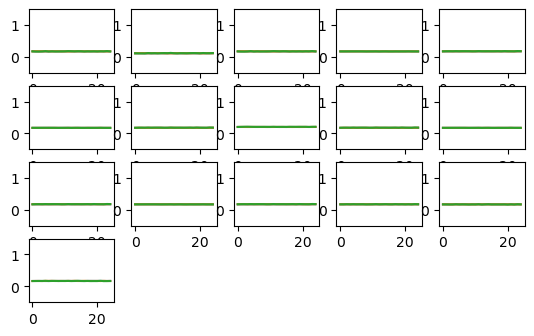

In [33]:
deltas_by_super_scenario = {}
for pp in range(subjs):
    plt.subplot(5,5,pp+1)

    for i, this_data in enumerate([ooo]):
        # print(i)
        for iz, z in enumerate(ooo.keys()):
            if 'herzfeld' not in z:
                continue
            else:
                scenario = z
                super_scenario = z.split('$')[0]
            deltas = []
            mm = lambda x: np.mean(x,axis=0)
            # scenario = f'herzfeld,z={z}'
            # this_result = this_data[scenario].mean(axis=1)
            print(f'processing subject {pp}, scenario {scenario}, result shape {this_data[scenario].shape}')
            # this_result = pooling_fun(this_data[scenario],axis=1)
            this_result = this_data[scenario][:,pp]
            pointer = 0
            for bb in range(25):
                block_length = len(this_result)//25
                # pointer += block_length
                # deltas.append(this_result[pointer-1]-this_result[pointer-3])
                deltas.append(this_result[pointer+2]-this_result[pointer])
                pointer += block_length

            if super_scenario not in deltas_by_super_scenario:
                deltas_by_super_scenario[super_scenario] = []
            deltas_by_super_scenario[super_scenario].append(deltas)
            # plt.plot(deltas,'x',label = f'z={z}')
            # plt.title('environmental consistency')
        # plt.legend(loc='upper right')
    # plt.figure()
        for k in deltas_by_super_scenario:
            # plt.plot(np.mean(deltas_by_super_scenario[k],axis=0),label=k)
            #present with error bars
            data = np.array(deltas_by_super_scenario[k])
            mean = np.nanmedian(data,axis=0)
            # std = np.std(data,axis=0)
            # plt.errorbar(np.arange(len(mean)),mean,yerr=std/np.sqrt(data.shape[0]),label=k)
            plt.plot(np.arange(len(mean)),mean,label=k)

        # plt.legend()
        # plt.title('environmental consistency')
        plt.ylim(-0.5,1.5)

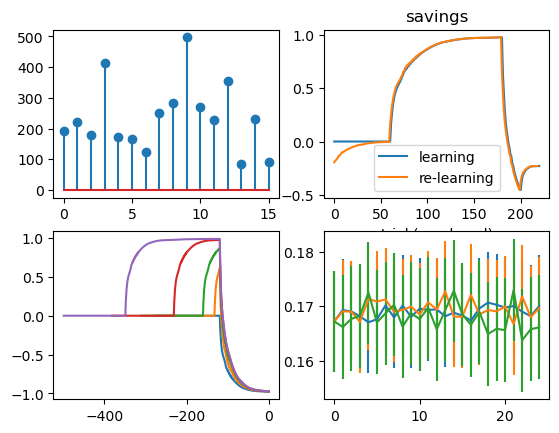

In [34]:
plt.subplot(2,2,1)
plt.stem(these_bics-coin_bics)
plt.subplot(2,2,2)
plt.plot(pooling_fun(ooo['savings'][:221], axis=1) , label='learning')
plt.plot(pooling_fun(ooo['savings'][221:], axis=1), label='re-learning')
# for subj in range(subjs):
    # plt.plot(ooo['savings'][221:, subj], color='gray', alpha=0.3)
plt.title('savings')
plt.xlabel('trial (overlayed)')
# plt.ylabel('adaptation')
plt.legend()
plt.subplot(2,2,3)
# plt.title('anterograde interference')
for ant in ant_list:
    x_data = np.arange(len(ooo[ant].mean(axis=1)))
    plt.plot(x_data-np.max(x_data),pooling_fun(ooo[ant], axis=1))
    # for subj in range(subjs):
    #     plt.plot(x_data-np.max(x_data),ooo[ant][:, subj], color='gray', alpha=0.3)
plt.subplot(2,2,4)
for k in deltas_by_super_scenario:
    # plt.plot(np.mean(deltas_by_super_scenario[k],axis=0),label=k)
    #present with error bars
    data = np.array(deltas_by_super_scenario[k])
    mean = pooling_fun(data,axis=0)
    std = np.std(data,axis=0)
    plt.errorbar(np.arange(len(mean)),mean,yerr=std/np.sqrt(data.shape[0]),label=k)
    # plt.plot(np.arange(len(mean)),mean,label=k)


(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,)
(25,

/tmp/ipykernel_2810281/3457295834.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


(-1.0, 1.2)

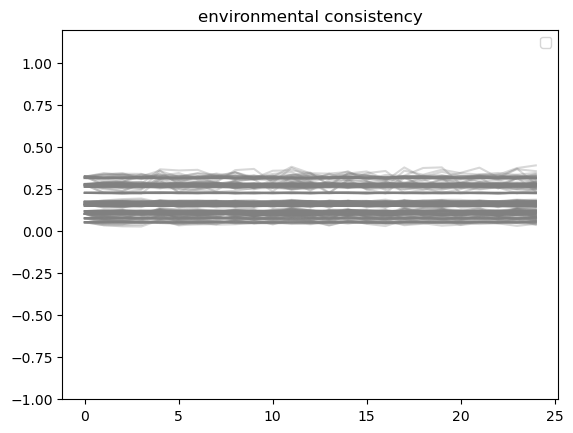

In [35]:
for k in deltas_by_super_scenario:
    # plt.plot(np.mean(deltas_by_super_scenario[k],axis=0),label=k)
    #present with error bars
    data = np.array(deltas_by_super_scenario[k])
    for datum in data:
        plt.plot(datum, color='gray', alpha=0.3)
        print(datum.shape)
    # mean = np.median(data,axis=0)
    # std = np.std(data,axis=0)
    # plt.errorbar(np.arange(len(mean)),mean,yerr=std/np.sqrt(data.shape[0]),label=k)
    # plt.plot(np.arange(len(mean)),mean,label=k)

plt.legend()
plt.title('environmental consistency')
plt.ylim(-1,1.2)

(-0.1, 1.1)

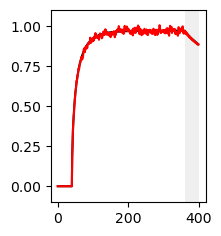

In [36]:
plt.figure(figsize=(2,2.5))
kk = 15/14
plt.plot(kk*ooo['albert_block_0'].mean(axis=1), label='noiseless albert block', color='black')

noisy_trials = [ooo[f'albert_block_{ii}'].mean(axis=1) for ii in range(1,101)]
plt.plot(kk*np.median(noisy_trials, axis=0), label='noisy albert blocks mean', color='red')
plt.axvspan(360, 400, facecolor='gray',  alpha=0.12, zorder=0)
plt.ylim(-0.1,1.1)


In [37]:
#histogram of best seed output scales
best_output_scales = model_state_dict['output_scale'].cpu().numpy().reshape([subjs, seeds])[np.arange(subjs), best_seed_idx]   

KeyError: 'output_scale'

In [ ]:
torch.nn.Sigmoid()(best_model_state_dict['direct_injection_scale']).numpy()

array([0.3876735 , 0.41395682, 0.5938439 , 0.30302906, 0.92954737,
       0.98436075, 0.05202028, 0.9235825 , 0.75132716, 0.50297165,
       0.25504613, 0.96147656, 0.16673568, 0.7371971 , 0.3223574 ,
       0.00521559], dtype=float32)

In [ ]:
best_params = {}
for key in model_state_dict.keys():
    if not key.startswith('_'):  # skip batchnorm running stats
        best_params[key] = model_state_dict[key].cpu().numpy().reshape([subjs, seeds])[np.arange(subjs), best_seed_idx]

In [ ]:
best_params

NameError: name 'best_params' is not defined

ValueError: num must be an integer with 1 <= num <= 16, not 17

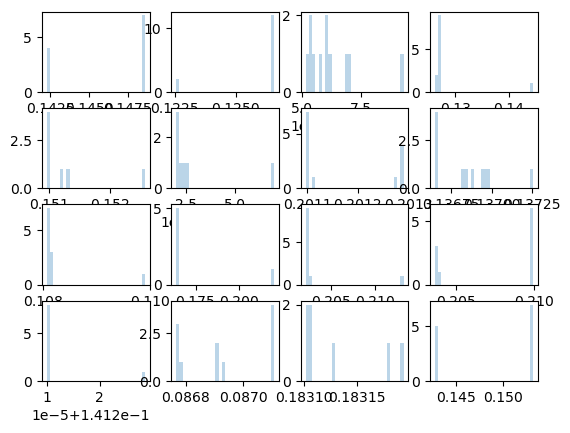

In [ ]:
plt.subplot(4,4,1)
for ii in range(subjs):
    plt.subplot(4,4,1+ii)
    plt.hist(rmse[ii,:], bins=30, alpha=0.3)

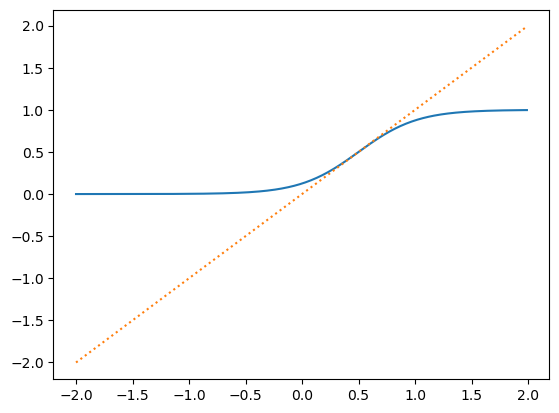

In [ ]:
sss = 0.4
nn = 1000
bbb = sss*np.random.normal(size=nn)
bbext = 0.2
xx = np.arange(-2,2,0.01)
yy = torch.nn.Sigmoid()(torch.tensor(4*xx.reshape(-1,1)-2+bbb.reshape(1,-1))).numpy().mean(axis=1)
plt.plot(xx, yy)
plt.plot(xx,xx,':')

In [ ]:
yy

array([4.90622430e-05, 5.10643916e-05, 5.31482395e-05, 5.53171200e-05,
       5.75745026e-05, 5.99239980e-05, 6.23693645e-05, 6.49145134e-05,
       6.75635157e-05, 7.03206085e-05, 7.31902014e-05, 7.61768842e-05,
       7.92854337e-05, 8.25208216e-05, 8.58882221e-05, 8.93930206e-05,
       9.30408223e-05, 9.68374604e-05, 1.00789007e-04, 1.04901780e-04,
       1.09182356e-04, 1.13637581e-04, 1.18274577e-04, 1.23100760e-04,
       1.28123845e-04, 1.33351863e-04, 1.38793173e-04, 1.44456473e-04,
       1.50350818e-04, 1.56485628e-04, 1.62870712e-04, 1.69516275e-04,
       1.76432939e-04, 1.83631758e-04, 1.91124238e-04, 1.98922353e-04,
       2.07038563e-04, 2.15485839e-04, 2.24277678e-04, 2.33428126e-04,
       2.42951803e-04, 2.52863924e-04, 2.63180322e-04, 2.73917476e-04,
       2.85092535e-04, 2.96723347e-04, 3.08828486e-04, 3.21427280e-04,
       3.34539847e-04, 3.48187121e-04, 3.62390889e-04, 3.77173822e-04,
       3.92559515e-04, 4.08572522e-04, 4.25238396e-04, 4.42583728e-04,
      

In [ ]:
best_model_state_dict['direct_injection_scale']

tensor([ 3.4163,  1.7405,  3.4644,  2.6034,  2.1464, -1.1416,  0.5109, -1.7547,
        -0.7255,  3.9701, -2.4011, -0.7610,  0.9591, -0.2366,  1.9101, -1.6879])

In [ ]:
best_model_state_dict['u_feedback_scale']

tensor([3.2426, 0.7467, 3.4014, 3.9861, 0.6672, 0.2233, 4.0189, 0.2895, 0.4347,
        0.7669, 3.2329, 0.0119, 2.0812, 1.7107, 1.1752, 0.1175])

In [ ]:
best_model_state_dict['log_learning_rate']

tensor([[-9.2844, -6.5187],
        [-5.6618, -6.8338],
        [-9.4918, -8.2347],
        [-9.8265, -6.6210],
        [-7.0658, -7.9097],
        [-5.7979, -4.7108],
        [-8.8067, -9.7687],
        [-5.5712, -4.5648],
        [-4.8586, -4.9815],
        [-7.3498, -5.9569],
        [-9.2861, -6.8720],
        [-6.1350, -7.1437],
        [-9.2973, -8.4109],
        [-8.9699, -7.3041],
        [-9.4614, -6.8860],
        [-5.4524, -5.7949]])

In [ ]:
best_model_state_dict['log_learning_rate']

tensor([[-3.4835, -0.7266],
        [-0.6504, -3.0329],
        [-3.3788, -1.4234],
        [-0.7935, -3.3933],
        [-3.3078, -1.2523],
        [-3.4359,  0.0353],
        [-3.2234, -2.0790],
        [-3.4073, -1.2520],
        [-0.9496, -3.2487],
        [-3.2406,  0.0630],
        [-2.9953, -1.2765],
        [-3.1567, -3.4871],
        [-3.6400, -1.5029],
        [-3.0121, -1.0767],
        [-5.8414, -0.9940],
        [-3.3609, -0.9197]])

In [ ]:
np.exp(best_model_state_dict['log_learning_rate'])*128


tensor([[0.0119, 0.1889],
        [0.4450, 0.1378],
        [0.0097, 0.0340],
        [0.0069, 0.1705],
        [0.1093, 0.0470],
        [0.3883, 1.1516],
        [0.0192, 0.0073],
        [0.4872, 1.3328],
        [0.9935, 0.8785],
        [0.0823, 0.3312],
        [0.0119, 0.1327],
        [0.2772, 0.1011],
        [0.0117, 0.0285],
        [0.0163, 0.0861],
        [0.0100, 0.1308],
        [0.5486, 0.3895]])

In [ ]:
model.debug_lr0.sum(axis=1)

NameError: name 'model' is not defined

In [ ]:
best_model_state_dict['sigma_b']

tensor([0.1507, 0.5088, 0.5217, 0.2390, 0.4501, 0.2041, 0.2554, 0.2920, 0.1240,
        0.3105, 0.2582, 0.3880, 0.1806, 0.4431, 0.0963, 0.4706])

In [ ]:
best_model_state_dict['sp_weight_decay']

tensor([[-7.0253, -2.2173],
        [-6.4083, -0.3292],
        [-5.6751,  1.4103],
        [ 0.0729, -6.9838],
        [-1.7333, -5.9443],
        [-5.5832,  0.6502],
        [-4.6110, -1.4350],
        [-5.7155,  0.9017],
        [-0.5803, -6.9070],
        [-5.2635,  0.4266],
        [-4.1996,  1.3261],
        [-3.1830, -6.7770],
        [-4.1871,  0.8330],
        [-4.4521, -0.6007],
        [-8.4699, -2.9765],
        [ 1.5468, -5.6760]])

In [ ]:
best_model_state_dict['output_scale']

tensor([1.0175, 1.0832, 0.8990, 0.9687, 0.9536, 0.9727, 0.8093, 1.1681, 0.9845,
        1.2220, 2.3499, 0.7986, 3.9132, 0.9858, 0.7938, 1.0301])

In [ ]:
best_model_state_dict['weight_decay_exp']

tensor([[2.0808],
        [0.9450],
        [1.1880],
        [2.1035],
        [1.1311],
        [1.1508],
        [0.6067],
        [1.1646],
        [2.0996],
        [2.0544],
        [0.5691],
        [1.4121],
        [0.6120],
        [0.6636],
        [1.6556],
        [1.1629]])

In [ ]:
best_model_state_dict['weight_learning_exp']

tensor([[0.5334],
        [0.5426],
        [0.6072],
        [0.5542],
        [0.7000],
        [0.6433],
        [1.1701],
        [0.5534],
        [0.5206],
        [0.5440],
        [1.1434],
        [0.6275],
        [0.6173],
        [1.2276],
        [1.6392],
        [0.6333]])

In [ ]:
model.args

namespace(apply_lr_decay=True,
          assume_opt_output_noise=True,
          bs=24,
          channel_trial_extra_error=0.0,
          direct_inj_limiter=1.0,
          disable_lpfs=True,
          enable_direct_injection=True,
          enable_elpf=False,
          enable_output_scale_tuning=True,
          enable_q_scale_tuning=True,
          enable_qlpf=False,
          enable_u_feedback_scale_tuning=False,
          enable_ylpf=False,
          injection_opt=3,
          lr_min_mult=0.1,
          model='default',
          model_tie_lr_weight_decay=False,
          multirate_m=1,
          n=256,
          nl_activation='relu',
          noise_injection_node='a',
          optimizer_alg='RMSprop',
          skip_gain=0.0,
          weight_decay_mode='softplus',
          zzz_legacy_init=False)

In [ ]:
ooo.keys()

dict_keys(['savings', 'AB0', 'AB1', 'AB2', 'AB3', 'AB4', 'AB5', 'spontaneous', 'evoked', 'visw1p2', 'visw1p1', 'visw1p3', 'albert_block_0', 'albert_block_1', 'albert_block_2', 'albert_block_3', 'albert_block_4', 'albert_block_5', 'albert_block_6', 'albert_block_7', 'albert_block_8', 'albert_block_9', 'albert_block_10', 'albert_block_11', 'albert_block_12', 'albert_block_13', 'albert_block_14', 'albert_block_15', 'albert_block_16', 'albert_block_17', 'albert_block_18', 'albert_block_19', 'albert_block_20', 'albert_block_21', 'albert_block_22', 'albert_block_23', 'albert_block_24', 'albert_block_25', 'albert_block_26', 'albert_block_27', 'albert_block_28', 'albert_block_29', 'albert_block_30', 'albert_block_31', 'albert_block_32', 'albert_block_33', 'albert_block_34', 'albert_block_35', 'albert_block_36', 'albert_block_37', 'albert_block_38', 'albert_block_39', 'albert_block_40', 'albert_block_41', 'albert_block_42', 'albert_block_43', 'albert_block_44', 'albert_block_45', 'albert_block_

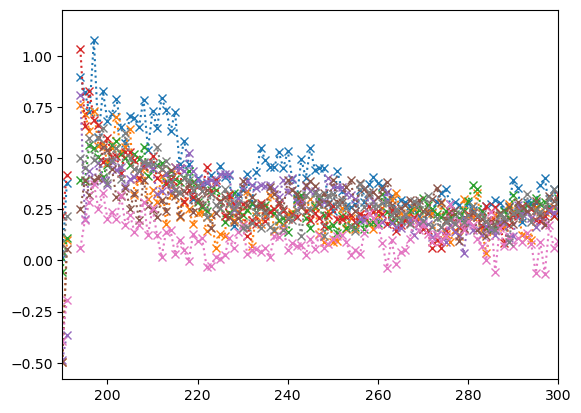

In [ ]:
for k in range(8):
    dd = a_exp[:,seeds*k]
    dd = dd*np.sign(np.nansum(dd))
    plt.plot(dd,':x')
    plt.xlim([190,300])

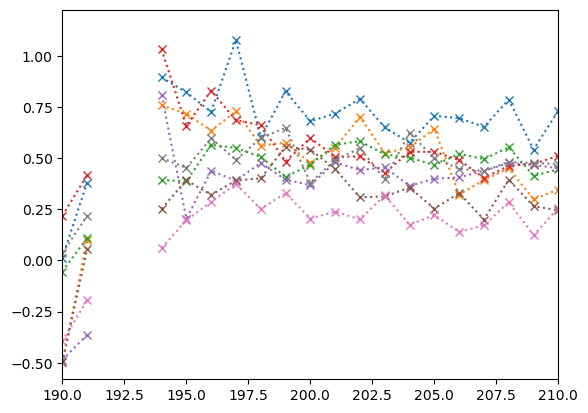

In [ ]:
for k in range(8):
    dd = a_exp[:,seeds*k]
    dd = dd*np.sign(np.nansum(dd))
    plt.plot(dd,':x')
    plt.xlim([190,210])

In [ ]:
p = np.sign(np.nansum(a_exp[:175,::seeds],axis=0))
dd = a_exp[:,::seeds]

Text(0.5, 1.0, 'ER: just before and just after the P+')

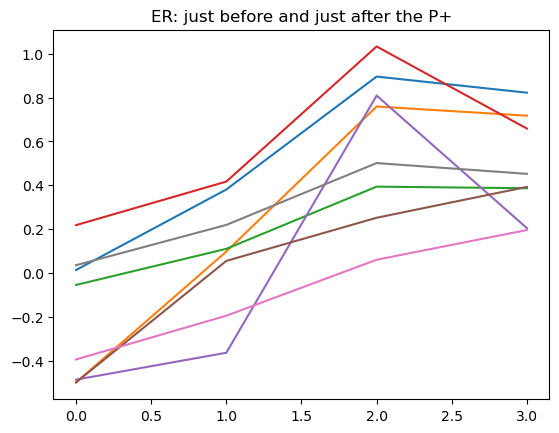

In [ ]:
plt.plot(dd[[190,191,194,195],:8]*p[:8])
plt.title('ER: just before and just after the P+')

(array([1., 0., 0., 0., 3., 3., 2., 3., 3., 1.]),
 array([-1.10669494, -0.97418321, -0.84167148, -0.70915975, -0.57664801,
        -0.44413628, -0.31162455, -0.17911282, -0.04660109,  0.08591064,
         0.21842237]),
 <BarContainer object of 10 artists>)

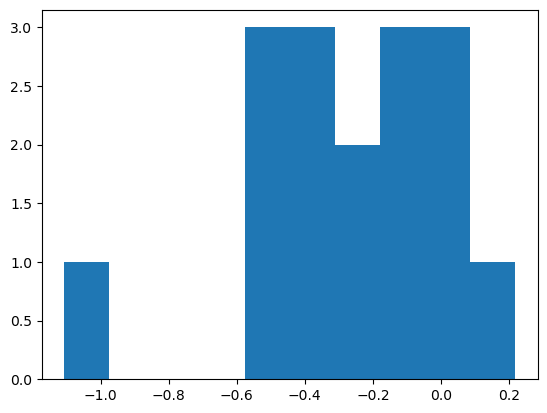

In [ ]:
plt.hist(dd[190,:]*p)

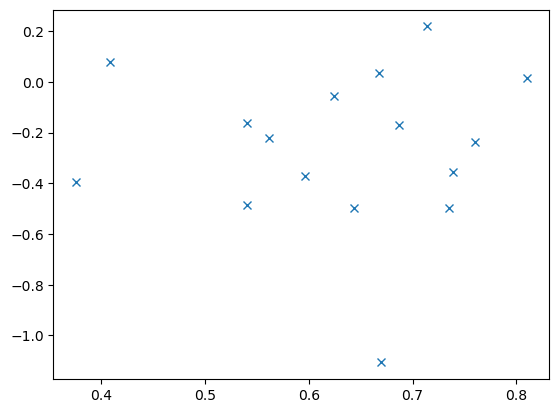

In [ ]:
plt.plot(np.nanmean(dd[50:80,:]*p, axis=0), dd[190,:]*p, 'x')

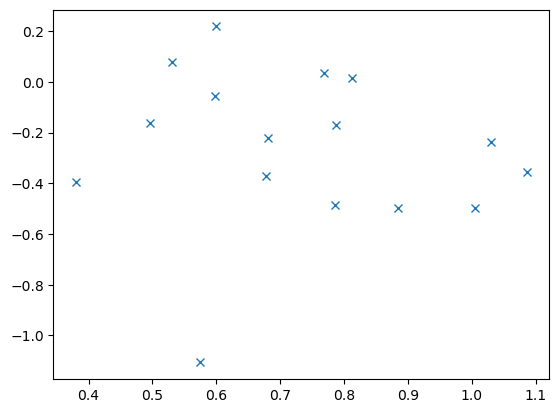

In [ ]:
plt.plot(np.nanmean(dd[60:70,:]*p, axis=0), dd[190,:]*p, 'x')

In [ ]:
from scipy.stats import spearmanr
spearmanr(np.nanmean(dd[60:70,:]*p, axis=0), dd[190,:]*p)

SignificanceResult(statistic=-0.22941176470588234, pvalue=0.39272049088161975)

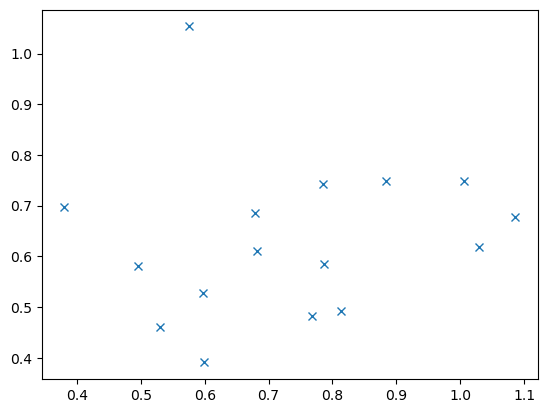

In [ ]:
plt.plot(np.nanmean(dd[60:70,:]*p, axis=0), (1-dd[190,:]*p)/2, 'x')

In [38]:
template = 'multirate'#'state-space'
mode = 'ERSR'
n_subjects = 1
n_seeds = 1
priority_intervals = None
priority_factor = None
if template == 'lr_reduct':
        args = SimpleNamespace(
        model='default',
        enable_q_scale_tuning= mode == 'MU',
        assume_opt_output_noise=True,
        enable_qlpf=False,
        enable_ylpf=False,
        enable_elpf=False,
        multirate_m=1,          # 
        apply_lr_decay=True, #False,
        noise_injection_node='a',
        model_tie_lr_weight_decay=False,
        bs=n_subjects * n_seeds,                      # IMPORTANT: one batch entry per subject
        zzz_legacy_init=False,
        enable_output_scale_tuning= True, #False,# mode == 'MU',
        enable_u_feedback_scale_tuning=False, #True,
        enable_direct_injection= True , #mode == 'MU',
        injection_opt=3,            # 
        skip_gain=0.0,
        channel_trial_extra_error=0.0,
        lr_min_mult = 1e-1,
        weight_decay_mode='softplus', #'sigmoid', #
        # weight_decay_mode='sigmoid',
        nl_activation='relu',
        n=128 if mode == 'ERSR' else 256,
        disable_lpfs=True,
        optimizer_alg='RMSprop',
        n_seeds=n_seeds,
        # direct_inj_limiter=0.45,
    )
elif template == 'multirate':
    args = SimpleNamespace(
        model='default',
        enable_q_scale_tuning= mode == 'MU',
        assume_opt_output_noise=True,
        enable_qlpf=False,
        enable_ylpf=False,
        enable_elpf=False,
        multirate_m=1,          # 
        apply_lr_decay=False, #False,
        noise_injection_node='a',
        model_tie_lr_weight_decay=False,
        bs=n_subjects * n_seeds,                      # IMPORTANT: one batch entry per subject
        zzz_legacy_init=False,
        enable_output_scale_tuning= False, #False,# mode == 'MU',
        enable_u_feedback_scale_tuning=False, #True,
        enable_direct_injection= True , #mode == 'MU',
        injection_opt=3,            # 
        skip_gain=0.0,
        channel_trial_extra_error=0.0,
        lr_min_mult = 1e-1,
        weight_decay_mode='softplus', #'sigmoid', #
        # weight_decay_mode='clipped_sigmoid',
        weight_decay_max=1.0,
        nl_activation= 'rescaled_sigmoid',#'rescaled_sigmoid',#'relu', #['relu', 'const'], # 'rescaled_sigmoid', #'relu', #
        n=128 if mode == 'ERSR' else 256,
        disable_lpfs=True,
        optimizer_alg= 'RMSprop', # 'RMSprop',
        n_seeds=n_seeds,
        priority_intervals=priority_intervals,
        priority_factor=priority_factor,
        lr_bound = None, #1./512.,
        bound_weight_decay = True,
        enable_weight_learning_exp = True,
        enable_weight_decay_exp = True,
        enable_bias_update = False,
        develop_b_tgt = -2.0,
        enable_w_in_plasticity = True,

        # direct_inj_limiter=0.45,
    )
elif template == 'state-space':
    args = SimpleNamespace(
        model='default',
        enable_q_scale_tuning= mode == 'MU',
        assume_opt_output_noise=True,
        enable_qlpf=False,
        enable_ylpf=False,
        enable_elpf=False,
        multirate_m=1,          # 
        apply_lr_decay=False, #False,
        noise_injection_node='a',
        model_tie_lr_weight_decay=False,
        bs=n_subjects * n_seeds,                      # IMPORTANT: one batch entry per subject
        zzz_legacy_init=False,
        enable_output_scale_tuning= False, #False,# mode == 'MU',
        enable_u_feedback_scale_tuning=False, #True,
        enable_direct_injection= False , #mode == 'MU',
        injection_opt=3,            # you’re using opt=2 in the model code
        skip_gain=0.0,
        channel_trial_extra_error=0.0,
        lr_min_mult = 1e-1,
        weight_decay_mode='softplus', #'sigmoid', #
        # weight_decay_mode='clipped_sigmoid',
        weight_decay_max=1.0,
        nl_activation='const', #['relu', 'const'], # 'rescaled_sigmoid', #'relu', #
        n=1 if mode == 'ERSR' else 256,
        disable_lpfs=True,
        optimizer_alg= 'RMSprop', # 'RMSprop',
        n_seeds=n_seeds,
        priority_intervals=priority_intervals,
        priority_factor=priority_factor,
        enable_sigma_b_tuning = False,
        lr_bound = None, #0.99,
        bound_weight_decay = True,
        enable_weight_decay_exp = True,
        enable_weight_learning_exp = True,
        enable_bias_update = True
        # direct_inj_limiter=0.45,
    )

In [39]:
model = BatchedElboGenerativeModelTopMulti(device=device, args=args).to(device)
model.get_biases_and_w_in(args.n, device=device)


(tensor([[ 0.0504, -0.6542,  0.1057,  0.8525, -0.0510,  0.0358,  0.2735, -0.2431,
           0.3110, -0.2728,  0.4888,  0.1611,  0.3387, -0.2516, -0.1031,  0.0723,
          -0.1146, -0.0565,  0.5255, -0.2016,  0.4458, -0.6245,  0.2140,  0.3246,
          -0.8554, -0.1893,  0.5485,  0.6955,  0.0921,  0.0433,  0.3781, -0.4911,
           0.2981,  0.0761, -0.2190, -0.3054, -0.2167, -0.0393,  0.1958,  0.0134,
          -0.0436, -0.0912,  0.2099,  0.0311, -0.2707, -0.7426,  0.1453, -0.0114,
          -0.4138, -0.4529,  0.4656, -0.6175, -0.4555, -0.5340, -0.3283,  0.1538,
          -0.1774, -0.2352,  0.1361,  0.0985,  0.5355, -0.1737,  0.0514, -0.6489,
           0.1751,  0.2077,  0.1641, -0.2215, -0.6385, -0.4455,  0.3846,  0.7606,
           0.1109,  0.0208,  0.2984,  0.1029,  0.1694,  0.3426, -0.0880,  0.3739,
           0.3389,  0.0367, -0.0415, -0.2672, -0.1364,  0.0655,  0.3116,  0.0716,
          -0.1372,  0.0047,  0.2006, -0.3774, -0.3000, -0.5203,  0.9797, -0.0913,
          -0.504

In [40]:
model_state_dict = model.state_dict()
k_params = compute_k_params(model_state_dict)

param: log_learning_rate, size: 1
param: sigma_b, size: 1
param: sp_weight_decay, size: 1
param: weight_decay_exp, size: 1
param: weight_learning_exp, size: 1
param: w_in_lr, size: 1
param: w_in_decay, size: 1
param: direct_injection_scale, size: 1


In [41]:
from model_utils import force_model_params




In [42]:
from optimise_clnn import load_subject_data

all_ys = []
all_a_exp = []
all_qs = []
lengths = []

mode =  'ERSR' #'ERSR' #'MU' 
paradigm_ = {k: 'evoked' if k <= 8 else 'spontaneous' for k in range(1, 17)}

for k in range(1, n_subjects + 1):
    if mode == 'ERSR':
        csv_path = f'/homes/ar2342/frogs_project/data/COIN_data/trial_data_{paradigm_[k]}_recovery_participant{(k-1)%8+1}.csv'
    else:
        csv_path = f'/homes/ar2342/frogs_project/data/COIN_data/trial_data_memory_updating_participant{k}.csv'
    experimental_data = load_subject_data(csv_path)

    a_exp = np.asarray(experimental_data[0], dtype=np.float32)  # target (your a_exp)
    ys    = np.asarray(experimental_data[1], dtype=np.float32)  # input ys (your ys)
    if mode == 'MU':
        qs = np.asarray(experimental_data[2], dtype=np.float32)  # input qs (your qs)

    for _ in range(n_seeds):
        all_a_exp.append(a_exp)
        all_ys.append(ys)
        if mode == 'MU':
            all_qs.append(qs)
        lengths.append(len(a_exp))

In [43]:
outputs = []
# pp_list = [0.25, 0.5,1,2,3]
pp_list = [0.0,3e-3,1e-2,3e-2,1e-1]
for pp in pp_list:
    forced_params = {
                    #'log_learning_rate_decay': -20., 
                    # 'sigma_x': 1e-7, 
                    'log_learning_rate': -5.50,
                    'sp_weight_decay': -6.5,
                    # 'output_scale': 1.0,
                    # 'u_feedback_scale': 1.0,
                    'sigma_b': 0.5,
                    #'q_scale': 0.9,
                    #  'tauelpf_m1': -1000.0,
                    #  'tauqlpf_m1': -1000.0,
                     'direct_injection_scale': 0.5,
                    'weight_decay_exp': 1.0,
                    'weight_learning_exp': 1.0,
                    'weight_decay_exp': 1.0,
                    'bias_lr':pp,
                    }
    force_model_params(model, forced_params)


    ys = torch.tensor(all_ys[0], device=next(model.parameters()).device)
    #duplicate ys across batch size
    ys = ys.unsqueeze(0).repeat(args.bs, 1)  # [bs, t]
    print(f'ys shape after unsqueeze and repeat: {ys.shape}')
    # noises = torch.randn((args.bs, ys.shape[1]), device=next(model.parameters()).device) * model.sigma_x  # [bs, t]
    noises = torch.zeros((args.bs, ys.shape[1]), device=next(model.parameters()).device)  # [bs, t]
    print(f'noises shape before splitting: {noises.shape}')
    noises = [noises[:, t_idx] for t_idx in range(noises.shape[1])]
    print(f'noises shape after splitting: {noises[0].shape}, number of noise tensors: {len(noises)}')
    ys = [ys[:, t_idx] for t_idx in range(ys.shape[1])]
    print(f'noises shape: {noises[0].shape}, ys shape: {ys[0].shape}')
    model_setting = args.model
    outputs_ = model.f(args.n,
                        noises,
                        ys,  
                        model_setting,
                        qs=None,
                        )
    outputs.append(np.array([z.cpu().detach().numpy().reshape(-1) for z in outputs_]))
# plt.ylim(-1.2,1.2)

Forcing parameter log_learning_rate to value -5.5
Forcing parameter sigma_b to value 0.5
Forcing parameter sp_weight_decay to value -6.5
Forcing parameter weight_decay_exp to value 1.0
Forcing parameter weight_learning_exp to value 1.0
Forcing parameter direct_injection_scale to value 0.5
ys shape after unsqueeze and repeat: torch.Size([1, 340])
noises shape before splitting: torch.Size([1, 340])
noises shape after splitting: torch.Size([1]), number of noise tensors: 340
noises shape: torch.Size([1]), ys shape: torch.Size([1])


/scratch/ar2342/miconda3/envs/py_frogs/lib/python3.9/site-packages/torch/nn/functional.py:1967: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


RuntimeError: einsum(): the number of subscripts in the equation (2) does not match the number of dimensions (3) for operand 1 and no ellipsis was given

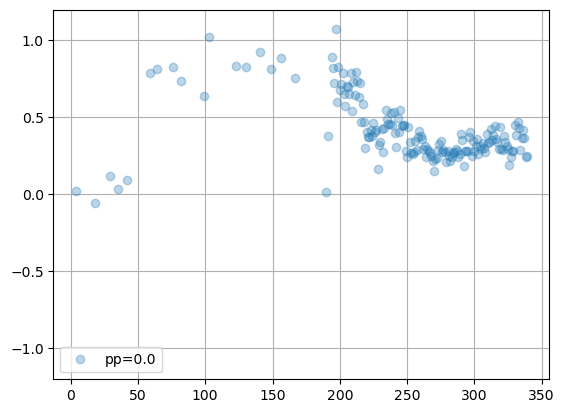

In [ ]:
for oo, out in enumerate(outputs):
    print(out.shape)
    plt.plot(out,'-')
plt.plot(a_exp, 'o',alpha=0.3)
plt.ylim(-1.2,1.2)
plt.legend([f'pp={pp}' for pp in pp_list]+['experimental'], loc='lower left')
# plt.plot(outputs[0],'-',linewidth=3, color='black')
# plt.xlim(188,200)#,53)
plt.grid()

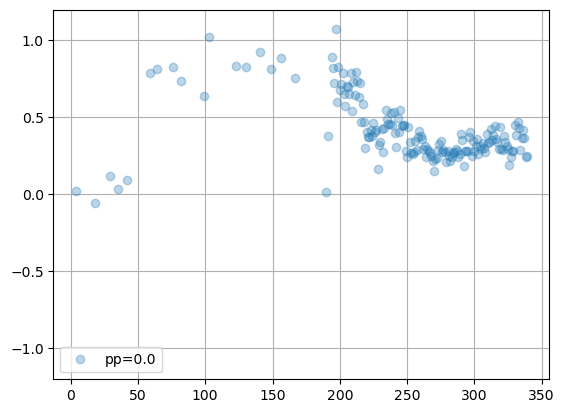

In [ ]:
for oo, out in enumerate(outputs):
    print(out.shape)
    plt.plot(out,'-')
plt.plot(a_exp, 'o',alpha=0.3)
plt.ylim(-1.2,1.2)
plt.legend([f'pp={pp}' for pp in pp_list]+['experimental'], loc='lower left')
# plt.plot(outputs[0],'-',linewidth=3, color='black')
# plt.xlim(188,200)#,53)
plt.grid()

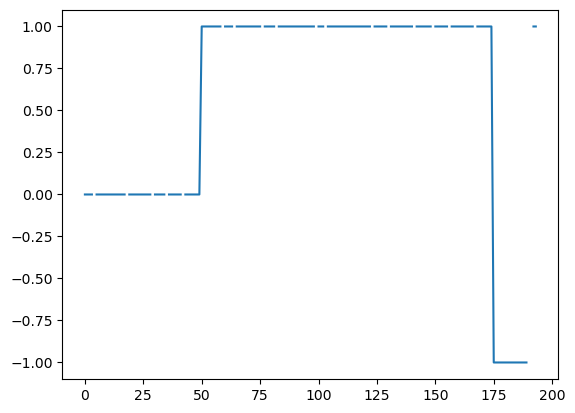

In [ ]:
plt.plot(all_ys[0])

In [ ]:
a_exp


array([        nan,         nan,         nan,         nan,  0.02277484,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan, -0.0534388 ,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,  0.12124509,
               nan,         nan,         nan,         nan,         nan,
        0.03530996,         nan,         nan,         nan,         nan,
               nan,         nan,  0.09142897,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,  0.7877995 ,
               nan,         nan,         nan,         nan,  0.8127609 ,
               nan,         nan,         nan,         nan,      

In [ ]:

def read_rmse_and_bic_from_path(bic_path,seeds):
    model_state_dict = torch.load(os.path.join(result_path, 'model_state_dict.pt'), map_location='cpu')
    k_params = compute_k_params(model_state_dict)
    print(f'detected k_params: {k_params}')
    a_exp = np.loadtxt(os.path.join(result_path, 'a_exp.txt'))
    a_pred = np.loadtxt(os.path.join(result_path, 'a_pred.txt'))

    subjs = a_exp.shape[1] // seeds

    rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])
    n_samples = np.sum(~np.isnan(a_exp),axis=0).reshape([subjs, seeds])
    assert np.all(n_samples == n_samples[:, [0]])
    n_samples = n_samples[:, 0]

    best_seed_idx = np.nanargmin(rmse, axis=1)
    best_rmse = rmse[np.arange(subjs), best_seed_idx]
    best_bics = [bic_gaussian_from_rmse(this_rmse, n=this_n, k=k_params) for this_rmse, this_n in zip(best_rmse, n_samples)]
    return {"best_rmse": np.array(best_rmse), "best_bics": np.array(best_bics)}

In [ ]:
ms = [1,2]
gs = [1,2]
clln_flags = [False, True]
outs = {}
for
for m in ms:
    for g in gs:
        result_path = f'/homes/ar2342/one_more_dir/contextual_frogs/results_part2/lerner_group{g}_{"CLNN" if clnn_flag else ""}m{m}/'
        '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/lerner_group1_CLNNm2/'
        outs[(g, m)] = read_rmse_and_bic_from_path(result_path, seeds=128)

param: log_learning_rate, size: 1
param: sp_weight_decay, size: 1
detected k_params: 2
param: log_learning_rate, size: 1
param: sp_weight_decay, size: 1
detected k_params: 2
param: log_learning_rate, size: 2
param: sp_weight_decay, size: 2
detected k_params: 4
param: log_learning_rate, size: 2
param: sp_weight_decay, size: 2
detected k_params: 4


In [ ]:
outs[(1,1)]['best_bics']-outs[(1,2)]['best_bics']

array([ 1.53560485, -9.54752792,  7.37023614, 12.47841224, -0.44289093,
       -1.55043901, 38.81441034,  0.25240403, -4.77504201, -9.02546367,
       41.37479934,  8.57411476, 33.84072816, -5.8933224 , -9.21326943,
       67.98959807])

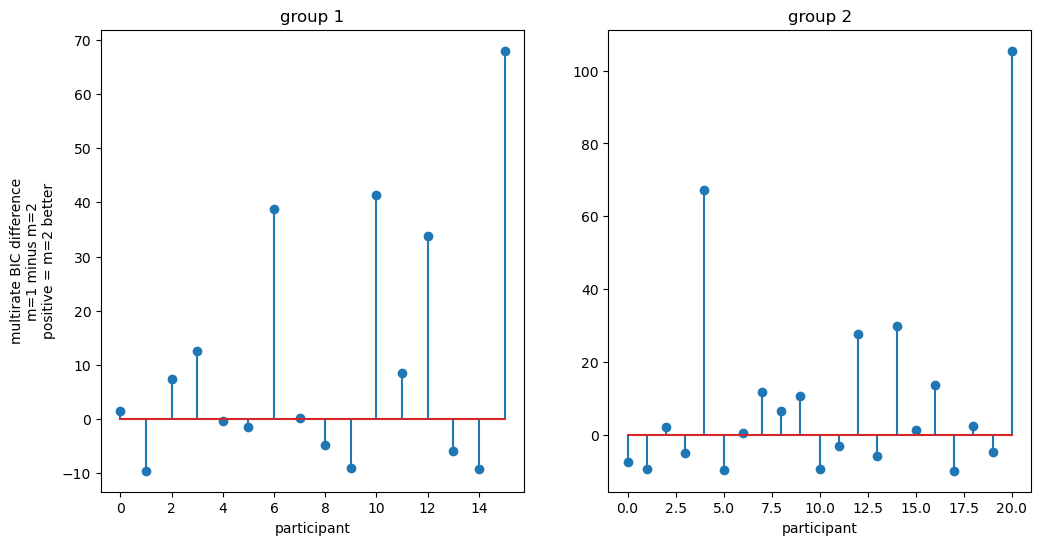

In [ ]:
plt.subplots(1,2, figsize=(12,6))
for i, g in enumerate(gs):
    plt.subplot(1,2,i+1)
    plt.stem(outs[(g,1)]['best_bics']-outs[(g,2)]['best_bics'])
    plt.title(f'group {g}')
    plt.xlabel('participant')
    if i==0:
        plt.ylabel('multirate BIC difference\nm=1 minus m=2\npositive = m=2 better')